# Assignment 1: From Dirty Data to Predictive Models
**Student Profile:** SDE Student
**Dataset:** Heart Disease Prediction (UCI Cleveland)

## 1. Introduction
This notebook demonstrates an end-to-end ML workflow to predict heart disease presence. We will clean 'dirty' clinical data, engineer features, and compare Generative (Naive Bayes) vs. Discriminative (Linear Regression) models.

## 2. Setup and Data Loading
We load the UCI Cleveland dataset. Missing values are documented as '?' in the raw text.

In [2]:
import urllib.request as retrieve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

url = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/processed.cleveland.data"

retrieve.urlretrieve(url, "processed.cleveland.data")

print("Dataset downloaded successfully.")

# Column names from heart-disease.names documentation
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# Load data - assuming processed.cleveland.data is in the same directory
df = pd.read_csv('processed.cleveland.data', header=None, names=columns, na_values='?')
print(f"Initial dataset shape: {df.shape}")
df.head()

Dataset downloaded successfully.
Initial dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Data Cleaning
We handle missing values using mode imputation and convert the target into a binary classification problem.

In [3]:
# Impute missing values (ca and thal) with the most frequent value (Mode)
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Binarize target: 0 (No Disease), 1-4 (Disease) -> 0/1
df_imputed['target'] = (df_imputed['num'] > 0).astype(int)
df_clean = df_imputed.drop('num', axis=1)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
df_clean['target'].value_counts()

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,count
target,
0,164
1,139


## 4. Feature Engineering
We apply One-Hot Encoding for categorical variables and Standard Scaling for numerical features to ensure a fair comparison for the Linear model.

In [4]:
# Define column types
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_cols = ['sex', 'fbs', 'exang']

# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Split Features and Target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Train/Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features after encoding: {X_train.shape[1]}")

Features after encoding: 18


## 5. Model Training
### 5.1 Naive Bayes (Generative)
We experiment with two different values of alpha for Laplace smoothing.

In [5]:
# NB with Alpha 1.0
nb_1 = BernoulliNB(alpha=1.0)
nb_1.fit(X_train_scaled, y_train)
y_pred_nb1 = nb_1.predict(X_test_scaled)

# NB with Alpha 0.01
nb_01 = BernoulliNB(alpha=0.01)
nb_01.fit(X_train_scaled, y_train)
y_pred_nb01 = nb_01.predict(X_test_scaled)

print(f"NB (alpha=1.0) Accuracy: {accuracy_score(y_test, y_pred_nb1):.4f}")
print(f"NB (alpha=0.01) Accuracy: {accuracy_score(y_test, y_pred_nb01):.4f}")

NB (alpha=1.0) Accuracy: 0.9180
NB (alpha=0.01) Accuracy: 0.8852


### 5.2 Linear Regression (Discriminative)
We apply a 0.5 probability threshold for classification and explore L1/L2 regularization.

In [6]:
# Base Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = (lr.predict(X_test_scaled) >= 0.5).astype(int)

# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = (ridge.predict(X_test_scaled) >= 0.5).astype(int)

# Lasso Regression (L1)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = (lasso.predict(X_test_scaled) >= 0.5).astype(int)

print(f"Linear Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Ridge (L2) Accuracy: {accuracy_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso (L1) Accuracy: {accuracy_score(y_test, y_pred_lasso):.4f}")

Linear Regression Accuracy: 0.8361
Ridge (L2) Accuracy: 0.8525
Lasso (L1) Accuracy: 0.8852


## 6. Evaluation
Visualizing performance using Confusion Matrices and the ROC Curve.

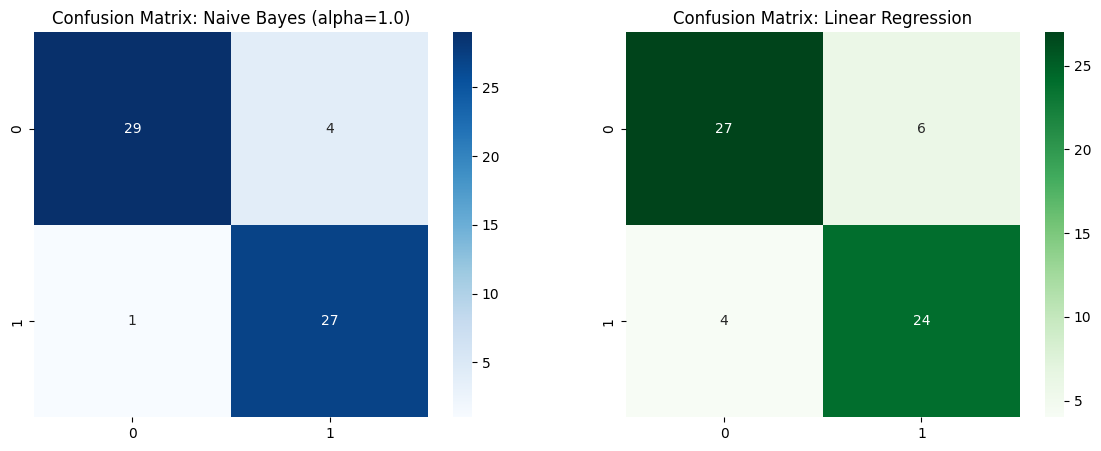

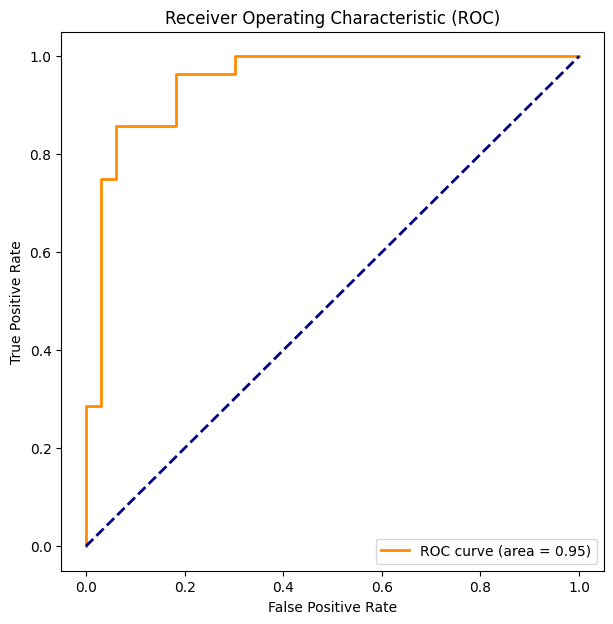

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix: Naive Bayes
sns.heatmap(confusion_matrix(y_test, y_pred_nb1), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Naive Bayes (alpha=1.0)')

# Confusion Matrix: Linear Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: Linear Regression')

plt.show()

# ROC Curve for Linear Regression
y_scores_lr = lr.predict(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_scores_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()